<div style="
  background-color:#CD5C5C;
  padding:20px;
  border-radius:12px;
  text-align:center;
  color:white;
  margin-bottom:20px;
">

  <h1 style="margin:0;">
    Data exploration — Scoring de défaut de crédit POC - GenAI
  </h1>

  <p style="margin:5px 0 0 0; font-size:16px;">
    Notebook 01 : Analyse Exploratoire des Données
  </p>

</div>

## Contexte

Ce notebook s'inscrit dans le projet **Scoring de Défaut de Crédit — POC GenAI « Talk to my Data »**. L'objectif est de construire un modèle de scoring capable d'identifier, parmi les clients porteurs d'une carte de crédit, ceux susceptibles de faire défaut le mois suivant.

**Dataset :** `credit_card_default.csv` — extrait des BigQuery ML datasets — **2 965 lignes** et **26 colonnes** représentant des clients d'une banque de détail (Taiwan).  
**Variable cible :** `default_payment_next_month` (binaire : 1 = défaut, 0 = pas de défaut).  
**Déséquilibre :** ~21 % de défauts → les métriques prioritaires seront le **PR-AUC** et le **Recall**.

> **Position dans le projet :** Ce notebook est le **point de départ**. Il précède toute modélisation et conditionne les décisions prises dans les notebooks 02 (baseline) et 03 (fine-tuning). Aucun modèle n'est entraîné ici — uniquement de l'exploration.

---

## Plan du notebook

**0. Imports & Split Train/Test**  
Chargement des données, suppression du leakage, split stratifié 80/20 (`random_state=1204`).

**1. Dictionnaire des données**  
Description des 26 variables et identification de la colonne de leakage (`predicted_default_payment_next_month`).

**2. Détection du leakage**  
Confirmation quantitative (ROC-AUC ~0.796, corrélation > 0.50) et exclusion définitive de la variable.

**3. Analyse de la variable cible**  
Distribution des classes, taux de défaut global (~21 %), stratégie face au déséquilibre.

**4. Analyse des variables socio-démographiques**  
Impact de `sex`, `education_level`, `marital_status` et `age` sur le taux de défaut.

**5. Historique de paiement**  
Analyse des `pay_0` … `pay_6` — prédicteurs les plus discriminants du dataset.

**6. Analyse des variables financières**  
`limit_balance`, `bill_amt`, `pay_amt` — distributions et corrélations avec la cible.

**7. Analyse de corrélation**  
Matrice de corrélation, identification des meilleurs prédicteurs, création de `utilization_proxy`.

**8. Synthèse EDA & protocole d'évaluation**  
Conclusions clés, recommandations de prétraitement, protocole d'évaluation pour la suite.

In [1]:
"""
Configuration de l'environnement
===================================================
Imports et configuration pour l'analyse exploratoire des données
"""

import os
import sys
import json

# Manipulation des données
import pandas as pd
import numpy as np

# Statistiques et tests
import scipy.stats as ss

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Modèles et évaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

# Seed pour la reproductibilité
RANDOM_STATE = 1204

# Répertoire de sauvegarde des figures
FIGURES_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'reports', 'figures'))
os.makedirs(FIGURES_DIR, exist_ok=True)

# Import de la fonction utilitaire depuis utils/data_prep.py
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.data_prep import detect_possible_outliers

print(f" Imports chargés avec succès")
print(f" Figures sauvegardées dans : {FIGURES_DIR}")

 Imports chargés avec succès
 Figures sauvegardées dans : c:\Users\juber\Documents\Projets Data\Scoring-de-defaut-de-credit-POC-GenAI-Talk-to-my-Data-\reports\figures


In [2]:
# Vérification du répertoire de travail
print(f" Répertoire courant : {os.getcwd()}")

 Répertoire courant : c:\Users\juber\Documents\Projets Data\Scoring-de-defaut-de-credit-POC-GenAI-Talk-to-my-Data-\notebooks


In [3]:
# ============================================================
# Chargement du dataset brut
# ============================================================
df = pd.read_csv("..\\data\\credit_card_default.csv")
print(f" Dataset importé : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")

 Dataset importé : 2965 lignes et 26 colonnes



In [4]:
# Aperçu des premières lignes du dataset
df.sample(10)

,id,limit_balance,sex,education_level,marital_status,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6,default_payment_next_month,predicted_default_payment_next_month
1111,17923.0,390000.0,1,3,1,49.0,0.0,0.0,0.0,0.0,...,285615.0,282611.0,12000.0,13000.0,12000.0,12000.0,10266.0,9800.0,0,"{\r\n ""predicted_default_payment_next_month"":..."
1675,22310.0,50000.0,2,2,2,27.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1500.0,3000.0,4000.0,0.0,0.0,0.0,0,"{\r\n ""predicted_default_payment_next_month"":..."
196,13806.0,230000.0,2,1,2,27.0,0.0,0.0,0.0,0.0,...,40391.0,35820.0,2963.0,1941.0,1534.0,1532.0,1565.0,1330.0,0,"{\r\n ""predicted_default_payment_next_month"":..."
2227,13887.0,230000.0,1,1,1,37.0,-1.0,-1.0,-1.0,-1.0,...,7652.0,17825.0,30580.0,5739.0,5799.0,7690.0,17914.0,360.0,0,"{\r\n ""predicted_default_payment_next_month"":..."
2390,19837.0,140000.0,2,2,1,35.0,-1.0,-1.0,-1.0,-1.0,...,326.0,326.0,326.0,6736.0,4246.0,326.0,326.0,502.0,0,"{\r\n ""predicted_default_payment_next_month"":..."
2929,6463.0,280000.0,2,1,2,52.0,-1.0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,930.0,0.0,0.0,0.0,0.0,0,"{\r\n ""predicted_default_payment_next_month"":..."
627,27995.0,220000.0,2,2,1,29.0,0.0,0.0,0.0,0.0,...,115256.0,97161.0,5042.0,5042.0,3687.0,3660.0,3528.0,3314.0,0,"{\r\n ""predicted_default_payment_next_month"":..."
273,15381.0,390000.0,2,1,2,30.0,0.0,0.0,0.0,0.0,...,55903.0,53516.0,5000.0,2506.0,3000.0,2500.0,2000.0,2000.0,0,"{\r\n ""predicted_default_payment_next_month"":..."
2609,5469.0,350000.0,2,1,2,33.0,-2.0,-2.0,-2.0,-2.0,...,-2.0,-2.0,0.0,0.0,0.0,0.0,0.0,940.0,0,"{\r\n ""predicted_default_payment_next_month"":..."
1127,26783.0,280000.0,1,3,2,30.0,0.0,0.0,0.0,0.0,...,115092.0,117496.0,4510.0,4654.0,4730.0,4119.0,4258.0,4292.0,0,"{\r\n ""predicted_default_payment_next_month"":..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2965 entries, 0 to 2964
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    2965 non-null   float64
 1   limit_balance                         2965 non-null   float64
 2   sex                                   2965 non-null   int64  
 3   education_level                       2965 non-null   int64  
 4   marital_status                        2965 non-null   int64  
 5   age                                   2965 non-null   float64
 6   pay_0                                 2965 non-null   float64
 7   pay_2                                 2965 non-null   float64
 8   pay_3                                 2965 non-null   float64
 9   pay_4                                 2965 non-null   float64
 10  pay_5                                 2965 non-null   int64  
 11  pay_6            

In [6]:
# ============================================================
# Constantes + split stratifié train / test
# ============================================================

# Colonnes clés du dataset
TARGET          = "default_payment_next_month"
LEAKAGE_COL     = "predicted_default_payment_next_month"
PAY_STATUS_COLS = ["pay_0", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6"]
BILL_COLS       = [f"bill_amt_{i}" for i in range(1, 7)]
PAY_AMT_COLS    = [f"pay_amt_{i}" for i in range(1, 7)]

# DataFrame de modélisation : leakage et id exclus dès la source
df_model = df.drop(columns=[LEAKAGE_COL, "id"]).copy()

# Split stratifié 80 / 20
FEATURES = [c for c in df_model.columns if c != TARGET]
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("=" * 52)
print("   Split Train / Test stratifié sur la cible")
print("=" * 52)
print(f"   Train : {X_train.shape[0]} lignes | Défaut = {y_train.mean()*100:.2f}%")
print(f"   Test  : {X_test.shape[0]} lignes  | Défaut = {y_test.mean()*100:.2f}%")
print("=" * 52)
print(f"   Features retenues : {len(FEATURES)}")


   Split Train / Test stratifié sur la cible
   Train : 2372 lignes | Défaut = 21.42%
   Test  : 593 lignes  | Défaut = 21.42%
   Features retenues : 23


> **Protocole** : le split est défini dès le chargement pour garantir qu'aucune information du jeu de test ne contamine l'exploration.  
> L'EDA suivante est réalisée sur le **dataset complet** pour visualiser les distributions globales ; toute décision de modélisation reposera sur `X_train` / `y_train` uniquement.  
> Le taux de défaut est bien préservé dans les deux splits grâce à la stratification sur la cible ✅



## 1. Dictionnaire des données

Le dataset est un extrait tabulaire issu des **BigQuery ML datasets** (défaut de carte de crédit).  
Il contient **2 965 lignes** et **26 colonnes** représentant des clients d'une banque de détail.

| Colonne | Type | Description |
|---|---|---|
| `id` | float | Identifiant unique client |
| `limit_balance` | float | Limite de crédit accordée (NTD) |
| `sex` | int | Genre — 1 = Homme, 2 = Femme |
| `education_level` | int | Niveau d'études — 1 = École sup., 2 = Université, 3 = Lycée, 4-6 = Autres/Inconnu |
| `marital_status` | int | Statut matrimonial — 1 = Marié(e), 2 = Célibataire, 3 = Autre, 0 = Inconnu |
| `age` | float | Âge du client (années) |
| `pay_0` … `pay_6` | float/int | Historique de paiement (M à M-6) — -2 = Pas de conso, -1 = Payé à temps, 0 = Revolving, 1+ = mois de retard |
| `bill_amt_1` … `bill_amt_6` | float | Montant facturé (M à M-6) en NTD |
| `pay_amt_1` … `pay_amt_6` | float | Montant payé (M à M-6) en NTD |
| `default_payment_next_month` | int | **Cible** — 1 = Défaut le mois suivant, 0 = Pas de défaut |
| `predicted_default_payment_next_month` | str | ⚠️ **LEAKAGE** — Prédiction d'un modèle existant à exclure des features |

> **Note pay_1 manquant** : la série saute de `pay_0` (mois M) à `pay_2` (M-2). `pay_0` est le mois le plus récent.


## 2. Contrôle qualité

In [7]:
# ============================================================
# 2.1 — Valeurs manquantes, doublons, types
# ============================================================

print("=" * 55)
print(f"  Dimensions        : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"  Valeurs manquantes: {df.isna().sum().sum()}")
print(f"  Doublons          : {df.duplicated().sum()}")
print("=" * 55)

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
})
quality


  Dimensions        : 2965 lignes × 26 colonnes
  Valeurs manquantes: 0
  Doublons          : 0


,dtype,non_null,missing_%,unique,min,max
age,float64,2965,0.0,49,21.0,69.0
bill_amt_1,float64,2965,0.0,2643,-11545.0,613860.0
bill_amt_2,float64,2965,0.0,2592,-67526.0,512650.0
bill_amt_3,float64,2965,0.0,2549,-25443.0,578971.0
bill_amt_4,float64,2965,0.0,2504,-46627.0,488808.0
bill_amt_5,float64,2965,0.0,2482,-46627.0,441981.0
bill_amt_6,float64,2965,0.0,2461,-73895.0,436172.0
default_payment_next_month,int64,2965,0.0,2,0.0,1.0
education_level,int64,2965,0.0,7,0.0,6.0
id,float64,2965,0.0,2965,29.0,29995.0


In [8]:
# ============================================================
# 2.2 — Détection de codes aberrants dans les variables catégorielles
# ============================================================
codes_edu = sorted(df["education_level"].unique())
codes_mar = sorted(df["marital_status"].unique())

print(f"Codes education_level présents : {codes_edu}")
print(f"  → Valeurs hors [1,2,3]        : {[v for v in codes_edu if v not in [1,2,3]]} ({df[~df['education_level'].isin([1,2,3])].shape[0]} lignes)")

print(f"\nCodes marital_status présents  : {codes_mar}")
print(f"  → Valeur 0 (inconnue)          : {(df['marital_status'] == 0).sum()} lignes")

print("\nDistribution des statuts de paiement (pay_X) :")
for col in PAY_STATUS_COLS:
    vals = sorted(df[col].unique())
    print(f"  {col} → {vals}")


Codes education_level présents : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  → Valeurs hors [1,2,3]        : [np.int64(0), np.int64(4), np.int64(5), np.int64(6)] (43 lignes)

Codes marital_status présents  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  → Valeur 0 (inconnue)          : 4 lignes

Distribution des statuts de paiement (pay_X) :
  pay_0 → [np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]
  pay_2 → [np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]
  pay_3 → [np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]
  pay_4 → [np.float64(-2.0), np.float64(-1.0), n

In [9]:
# ============================================================
# 2.3 — Alerte LEAKAGE : colonne predicted_default_payment_next_month
# ============================================================
def extract_proba_default(raw):
    """Extrait la probabilité de défaut (value='1') du JSON BigQuery."""
    try:
        rows = json.loads(raw)["predicted_default_payment_next_month"]
        for row in rows:
            if row["tables"]["value"] == "1":
                return float(row["tables"]["score"])
    except Exception:
        return np.nan

leak_score = df[LEAKAGE_COL].apply(extract_proba_default)

roc  = roc_auc_score(df[TARGET], leak_score)
pr   = average_precision_score(df[TARGET], leak_score)
corr = leak_score.corr(df[TARGET])

print("=" * 52)
print("   ANALYSE DE LA COLONNE DE LEAKAGE")
print("=" * 52)
print(f"   ROC-AUC avec la cible    : {roc:.4f}")
print(f"   PR-AUC  avec la cible    : {pr:.4f}")
print(f"   Correlation Pearson      : {corr:.4f}")
print("-" * 52)
print("   ROC-AUC > 0.79 => FUITE CONFIRMEE")
print("   Cette colonne ne doit JAMAIS etre une feature")
print("=" * 52)


   ANALYSE DE LA COLONNE DE LEAKAGE
   ROC-AUC avec la cible    : 0.7961
   PR-AUC  avec la cible    : 0.5917
   Correlation Pearson      : 0.5067
----------------------------------------------------
   ROC-AUC > 0.79 => FUITE CONFIRMEE
   Cette colonne ne doit JAMAIS etre une feature


> ⚠️ **Fuite de données confirmée** : la colonne `predicted_default_payment_next_month` atteint un ROC-AUC de ~0.796 et une corrélation de Pearson > 0.50 avec la cible — elle a été produite à partir de la variable cible elle-même.  
> Elle a été **exclue dès le début** via `df_model = df.drop(columns=[LEAKAGE_COL, "id"])`.  
> Toute analyse ou modèle incluant cette colonne produirait des performances artificiellement gonflées.


## 3. Analyse de la variable cible — Déséquilibre des classes

> **Enjeu métier** : La direction *Recouvrement & Risque* cherche à identifier les clients qui vont faire défaut le mois suivant.  
> Avec ~21 % de défauts, le dataset est **déséquilibré** — l'accuracy serait trompeuse.  
> On privilégiera le **PR-AUC** (Precision-Recall AUC) et le **Recall**.


Taux de défaut global : 21.42%

default_payment_next_month
Non-défaut (0)    2330
Défaut (1)         635


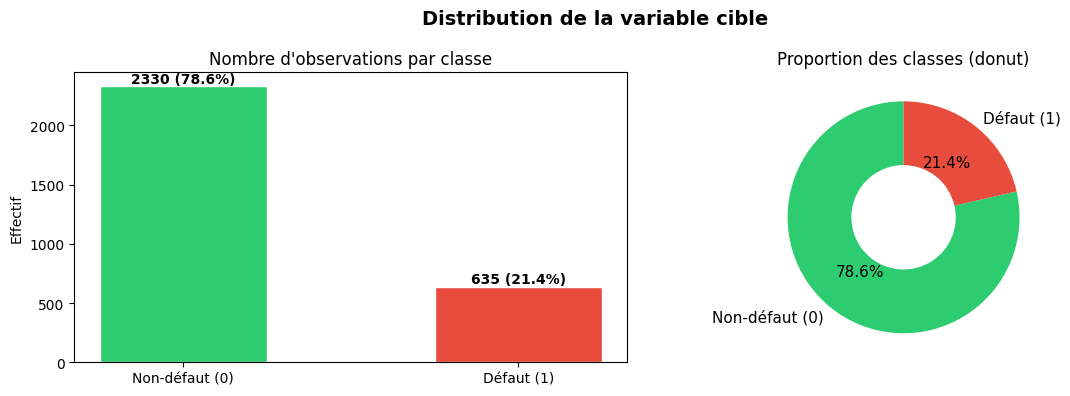

In [10]:
# ============================================================
# 3.1 — Distribution de la cible
# ============================================================
target_counts = df[TARGET].value_counts().sort_index()
target_pct    = df[TARGET].value_counts(normalize=True).sort_index() * 100

print(f"Taux de défaut global : {df[TARGET].mean()*100:.2f}%\n")
print(target_counts.rename({0: "Non-défaut (0)", 1: "Défaut (1)"}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution de la variable cible", fontsize=14, fontweight="bold")

colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(["Non-défaut (0)", "Défaut (1)"], target_counts, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Nombre d'observations par classe")
axes[0].set_ylabel("Effectif")
for i, (val, pct) in enumerate(zip(target_counts, target_pct)):
    axes[0].text(i, val + 30, f"{val} ({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")

wedges, _, autotexts = axes[1].pie(
    target_counts, labels=["Non-défaut (0)", "Défaut (1)"],
    autopct="%1.1f%%", startangle=90, colors=colors,
    wedgeprops=dict(width=0.55), textprops={"fontsize": 11}
)
axes[1].set_title("Proportion des classes (donut)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation :**

- Le taux de défaut global est de **~21 %** : environ 1 client sur 5 fait défaut le mois suivant.
- Le dataset est **déséquilibré** (ratio 1:3.7) — l'*accuracy* serait trompeuse comme seule métrique.
- → Stratégie recommandée : `class_weight='balanced'` ou SMOTE, avec le **PR-AUC** comme métrique prioritaire.


## 4. Analyse des variables socio-démographiques

Variables : `sex`, `education_level`, `marital_status`, `age`


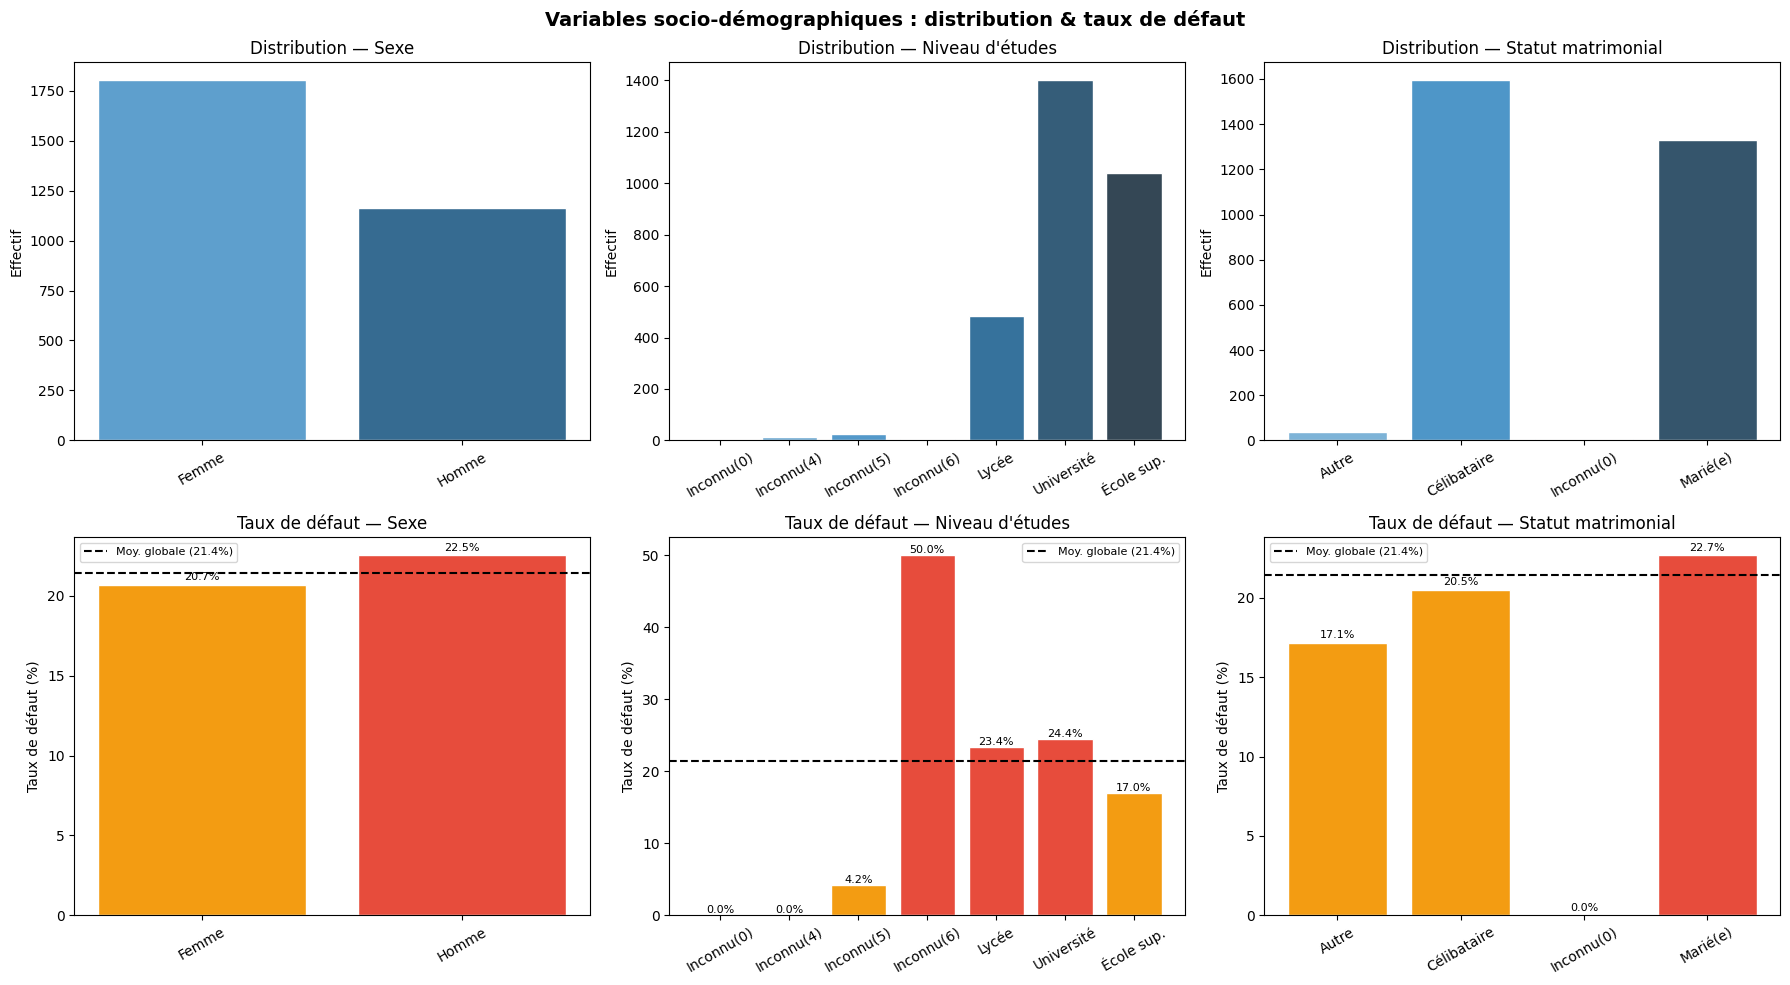

In [11]:
# ============================================================
# 4.1 — Distributions et taux de défaut par segment socio-démo
# ============================================================
sex_map     = {1: "Homme", 2: "Femme"}
edu_map     = {0: "Inconnu(0)", 1: "École sup.", 2: "Université", 3: "Lycée",
               4: "Inconnu(4)", 5: "Inconnu(5)", 6: "Inconnu(6)"}
marital_map = {0: "Inconnu(0)", 1: "Marié(e)", 2: "Célibataire", 3: "Autre"}

df_plot = df.copy()
df_plot["sex_label"]     = df_plot["sex"].map(sex_map)
df_plot["edu_label"]     = df_plot["education_level"].map(edu_map)
df_plot["marital_label"] = df_plot["marital_status"].map(marital_map)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Variables socio-démographiques : distribution & taux de défaut", fontsize=14, fontweight="bold")

def plot_segment(ax_dist, ax_rate, series, target_series, title):
    counts  = series.value_counts().sort_index()
    rate_df = pd.DataFrame({"label": series, "target": target_series})
    rate    = rate_df.groupby("label")["target"].mean().sort_index() * 100
    global_rate = target_series.mean() * 100

    palette_dist = sns.color_palette("Blues_d", len(counts))
    ax_dist.bar(counts.index.astype(str), counts.values, color=palette_dist, edgecolor="white")
    ax_dist.set_title(f"Distribution — {title}")
    ax_dist.set_ylabel("Effectif")
    ax_dist.tick_params(axis="x", rotation=30)

    palette_rate = ["#e74c3c" if v > global_rate else "#f39c12" for v in rate.values]
    bars = ax_rate.bar(rate.index.astype(str), rate.values, color=palette_rate, edgecolor="white")
    ax_rate.axhline(global_rate, color="black", linestyle="--", linewidth=1.5,
                    label=f"Moy. globale ({global_rate:.1f}%)")
    ax_rate.set_title(f"Taux de défaut — {title}")
    ax_rate.set_ylabel("Taux de défaut (%)")
    ax_rate.legend(fontsize=8)
    ax_rate.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, rate.values):
        ax_rate.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f"{val:.1f}%", ha="center", fontsize=8)

plot_segment(axes[0, 0], axes[1, 0], df_plot["sex_label"],     df[TARGET], "Sexe")
plot_segment(axes[0, 1], axes[1, 1], df_plot["edu_label"],     df[TARGET], "Niveau d'études")
plot_segment(axes[0, 2], axes[1, 2], df_plot["marital_label"], df[TARGET], "Statut matrimonial")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_socio_demo.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation :**

- Les **hommes** présentent un taux légèrement plus élevé que les femmes (~22.5 % vs ~20.7 %).
- Niveaux **Université** (2) et **Lycée** (3) : taux > 24 %, supérieur aux diplômés de grandes écoles.
- Les codes 0, 4, 5, 6 (catégories non documentées) sont marginaux (< 2.5 %) → à regrouper en « Autre ».
- Les **mariés** affichent un risque légèrement supérieur aux célibataires.


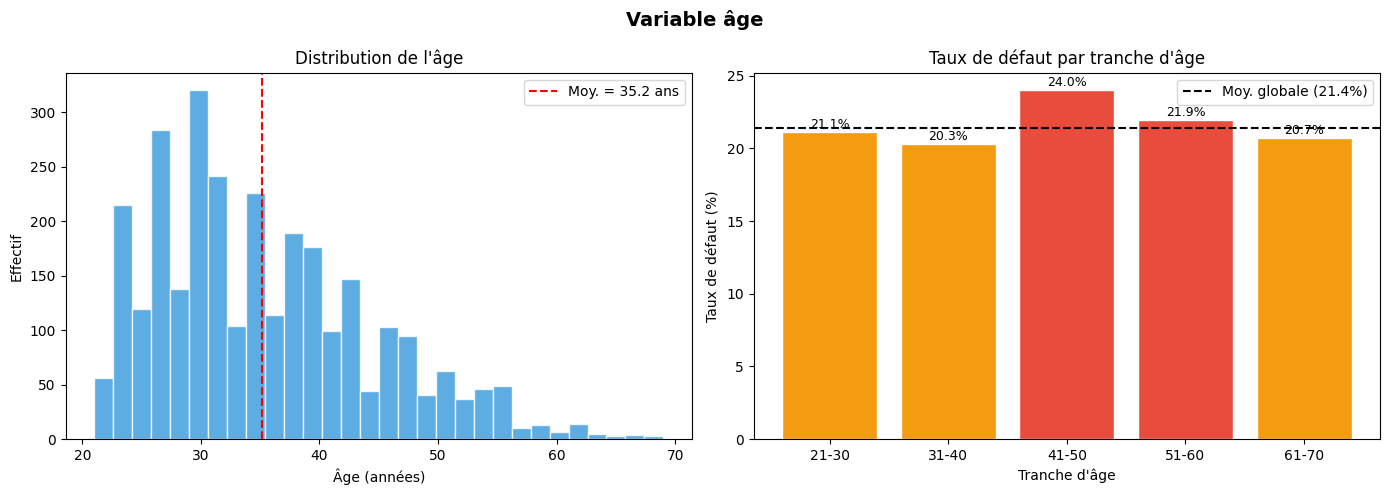

In [12]:
# ============================================================
# 4.2 — Distribution de l'âge et taux de défaut par tranche
# ============================================================
df_plot["age_bin"] = pd.cut(df_plot["age"], bins=[20, 30, 40, 50, 60, 70],
                             labels=["21-30", "31-40", "41-50", "51-60", "61-70"])
age_rate = df_plot.groupby("age_bin", observed=True)[TARGET].agg(["count", "mean"]).reset_index()
age_rate["mean_pct"] = age_rate["mean"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Variable âge", fontsize=14, fontweight="bold")

axes[0].hist(df_plot["age"], bins=30, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribution de l'âge")
axes[0].set_xlabel("Âge (années)")
axes[0].set_ylabel("Effectif")
axes[0].axvline(df_plot["age"].mean(), color="red", linestyle="--",
                label=f"Moy. = {df_plot['age'].mean():.1f} ans")
axes[0].legend()

axes[1].bar(age_rate["age_bin"].astype(str), age_rate["mean_pct"],
            color=["#e74c3c" if v > df[TARGET].mean()*100 else "#f39c12" for v in age_rate["mean_pct"]],
            edgecolor="white")
axes[1].axhline(df[TARGET].mean() * 100, color="black", linestyle="--", linewidth=1.5,
                label=f"Moy. globale ({df[TARGET].mean()*100:.1f}%)")
axes[1].set_title("Taux de défaut par tranche d'âge")
axes[1].set_xlabel("Tranche d'âge")
axes[1].set_ylabel("Taux de défaut (%)")
axes[1].legend()
for i, row in age_rate.iterrows():
    axes[1].text(i, row["mean_pct"] + 0.3, f"{row['mean_pct']:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_age_default.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation :**

- L'âge moyen du dataset est d'environ **35 ans**.
- Les **21-30 ans** présentent le taux de défaut le plus élevé — profil de risque maximal.
- Le taux **diminue avec l'âge** : corrélation négative avec la maturité financière et la stabilité de revenus.


## 5. Analyse de l'historique de paiement

> Les colonnes `pay_0` à `pay_6` encodent le **statut de remboursement mensuel** sur les 6 derniers mois.  
> Code : -2 = pas de consommation, -1 = payé à temps, 0 = crédit renouvelable, 1+ = mois de retard.  
> `pay_0` est le mois le plus récent (M), `pay_2` = M-2, etc. (`pay_1` est absent du dataset).  
> **Ce sont les variables les plus corrélées avec le défaut** (corr. pay_0 = 0.36).


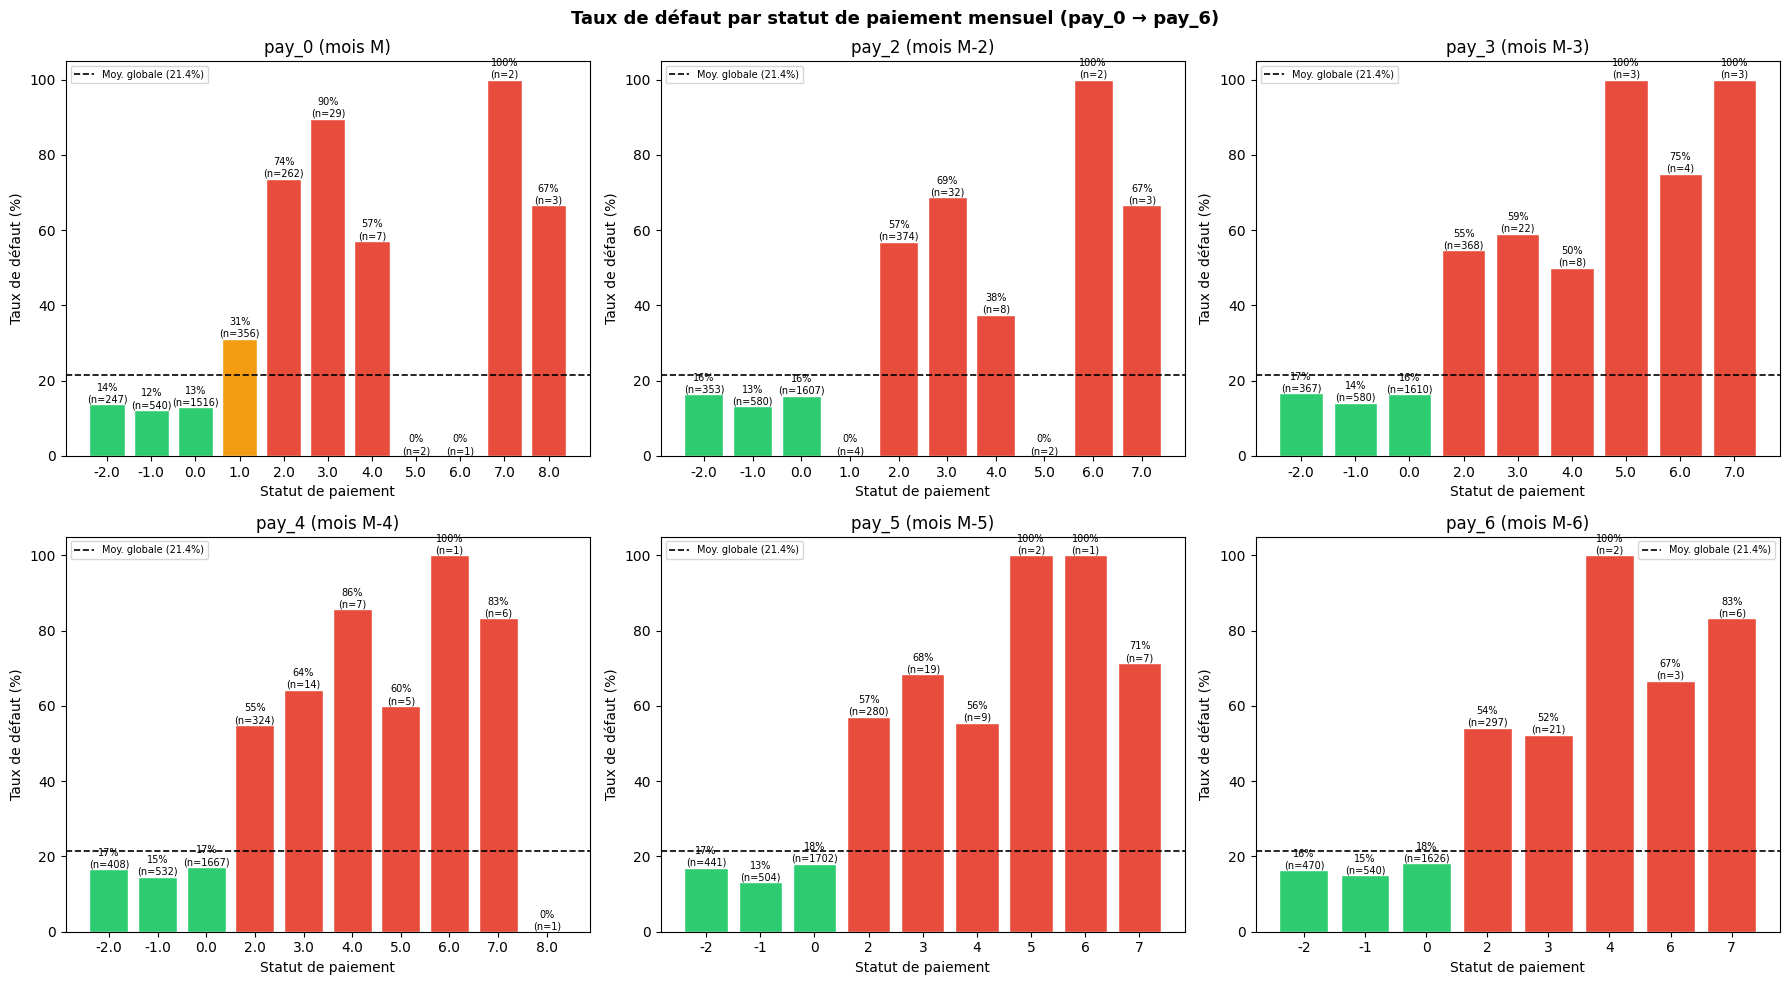

In [13]:
# ============================================================
# 5.1 — Taux de défaut par statut de paiement (pay_0 à pay_6)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Taux de défaut par statut de paiement mensuel (pay_0 → pay_6)", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(PAY_STATUS_COLS):
    rate   = df.groupby(col)[TARGET].mean().sort_index() * 100
    counts = df[col].value_counts().sort_index()
    color_list = ["#e74c3c" if v >= 2 else "#f39c12" if v == 1 else "#2ecc71" for v in rate.index]

    bars = axes[i].bar(rate.index.astype(str), rate.values, color=color_list, edgecolor="white")
    axes[i].axhline(df[TARGET].mean() * 100, color="black", linestyle="--", linewidth=1.2,
                    label=f"Moy. globale ({df[TARGET].mean()*100:.1f}%)")
    axes[i].set_title(f"{col} (mois {'M' if col == 'pay_0' else 'M-' + col[-1]})")
    axes[i].set_xlabel("Statut de paiement")
    axes[i].set_ylabel("Taux de défaut (%)")
    axes[i].legend(fontsize=7)
    for bar, (val, cnt) in zip(bars, zip(rate.values, counts.reindex(rate.index, fill_value=0).values)):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{val:.0f}%\n(n={cnt})", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_pay_status_default.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation :**

- Un **statut ≥ 2** (retard ≥ 2 mois) entraîne un taux de défaut > 55 % sur `pay_0`, pouvant atteindre ~90 % pour 3 mois de retard.
- Les statuts **-2 ou -1** (pas de consommation / payé à temps) restent proches de 13-16 %.
- `pay_0` (mois le plus récent) est le **signal le plus fort** : corrélation de Pearson = 0.36 avec la cible.


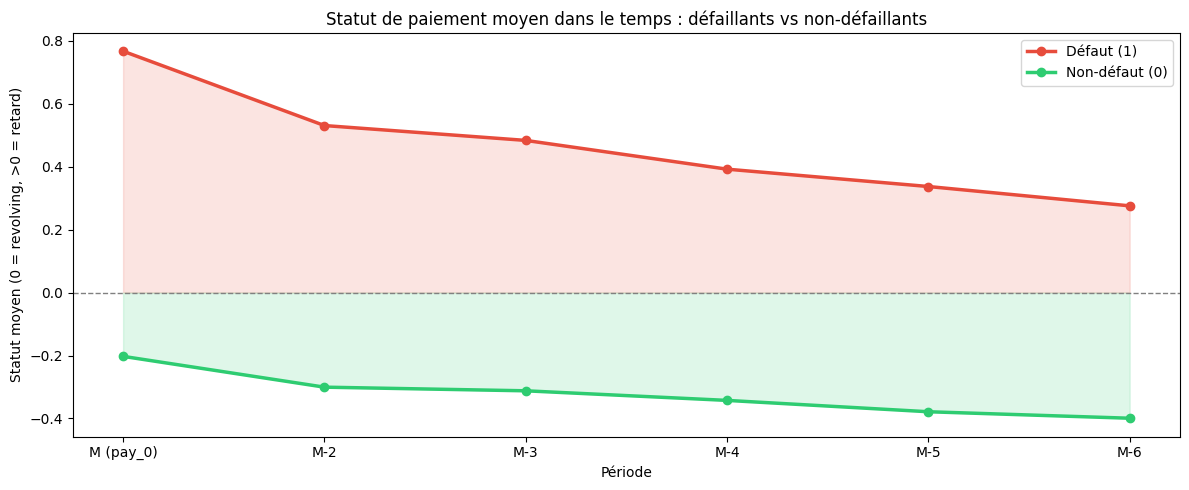

In [14]:
# ============================================================
# 5.2 — Évolution du statut de paiement moyen dans le temps
#       défaillants vs non-défaillants
# ============================================================
pay_means = df.groupby(TARGET)[PAY_STATUS_COLS].mean()
months_labels = ["M (pay_0)", "M-2", "M-3", "M-4", "M-5", "M-6"]

fig, ax = plt.subplots(figsize=(12, 5))
for label_val, label_txt, color in [(1, "Défaut (1)", "#e74c3c"), (0, "Non-défaut (0)", "#2ecc71")]:
    ax.plot(months_labels, pay_means.loc[label_val].values, marker="o",
            linewidth=2.5, label=label_txt, color=color)
    ax.fill_between(months_labels, pay_means.loc[label_val].values, alpha=0.15, color=color)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Statut de paiement moyen dans le temps : défaillants vs non-défaillants", fontsize=12)
ax.set_xlabel("Période")
ax.set_ylabel("Statut moyen (0 = revolving, >0 = retard)")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_pay_trend.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation :**

- Les **défaillants** ont un statut de paiement moyen significativement plus élevé sur toute la période (tendance au retard persistant).
- La dégradation est visible dès `pay_0` et se confirme sur les mois précédents.
- Les **non-défaillants** restent proches de 0 (crédit renouvelable utilisé normalement, remboursements à temps).


## 6. Analyse des variables financières

Variables : `limit_balance`, `bill_amt_1..6`, `pay_amt_1..6`


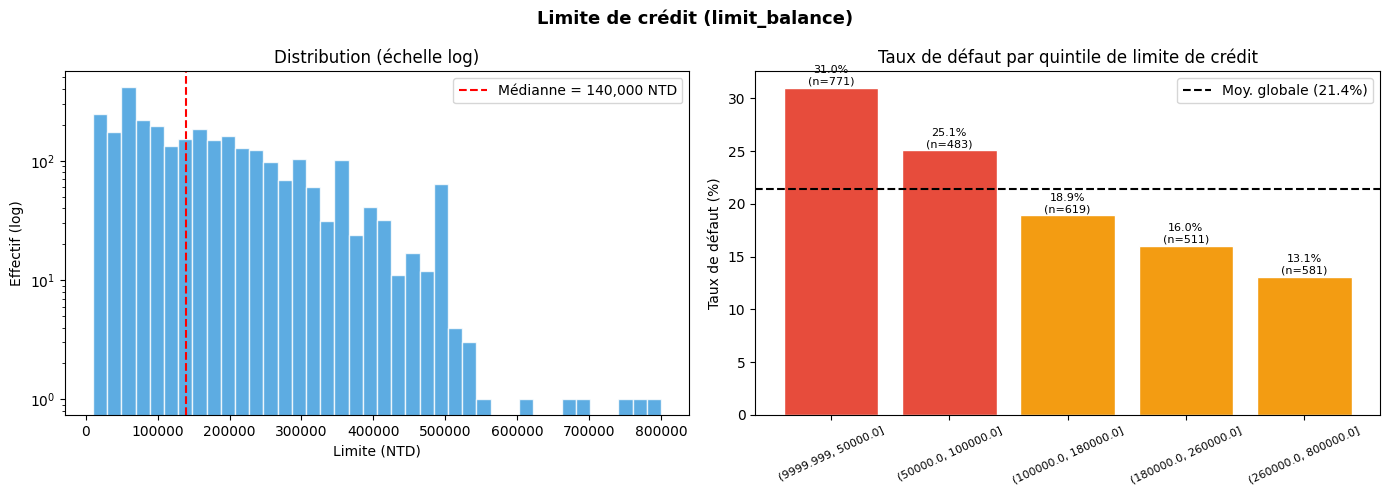

In [15]:
# ============================================================
# 6.1 — Limite de crédit : distribution + taux de défaut par quintile
# ============================================================
df["limit_bin"] = pd.qcut(df["limit_balance"], q=5, duplicates="drop")
limit_rate = df.groupby("limit_bin", observed=True)[TARGET].agg(["count", "mean"]).reset_index()
limit_rate["mean_pct"] = limit_rate["mean"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Limite de crédit (limit_balance)", fontsize=13, fontweight="bold")

axes[0].hist(df["limit_balance"], bins=40, color="#3498db", edgecolor="white", alpha=0.8, log=True)
axes[0].set_title("Distribution (échelle log)")
axes[0].set_xlabel("Limite (NTD)")
axes[0].set_ylabel("Effectif (log)")
axes[0].axvline(df["limit_balance"].median(), color="red", linestyle="--",
                label=f"Médianne = {df['limit_balance'].median():,.0f} NTD")
axes[0].legend()

axes[1].bar(range(len(limit_rate)), limit_rate["mean_pct"],
            color=["#e74c3c" if v > df[TARGET].mean()*100 else "#f39c12" for v in limit_rate["mean_pct"]],
            edgecolor="white")
axes[1].axhline(df[TARGET].mean() * 100, color="black", linestyle="--", linewidth=1.5,
                label=f"Moy. globale ({df[TARGET].mean()*100:.1f}%)")
axes[1].set_xticks(range(len(limit_rate)))
axes[1].set_xticklabels([str(b) for b in limit_rate["limit_bin"]], rotation=25, fontsize=8)
axes[1].set_title("Taux de défaut par quintile de limite de crédit")
axes[1].set_ylabel("Taux de défaut (%)")
axes[1].legend()
for i, row in limit_rate.iterrows():
    axes[1].text(i, row["mean_pct"] + 0.3,
                 f"{row['mean_pct']:.1f}%\n(n={row['count']})", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_limit_balance.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation :**

- **Corrélation négative avec la cible (-0.16)** : plus la limite accordée est élevée, moins le risque de défaut est important.
- Quintile le plus bas (< 50k NTD) → taux de défaut ~31 % (2.4× la moyenne globale).
- Quintile le plus haut (> 260k NTD) → taux de ~13 % : profil clientèle plus solide financièrement.


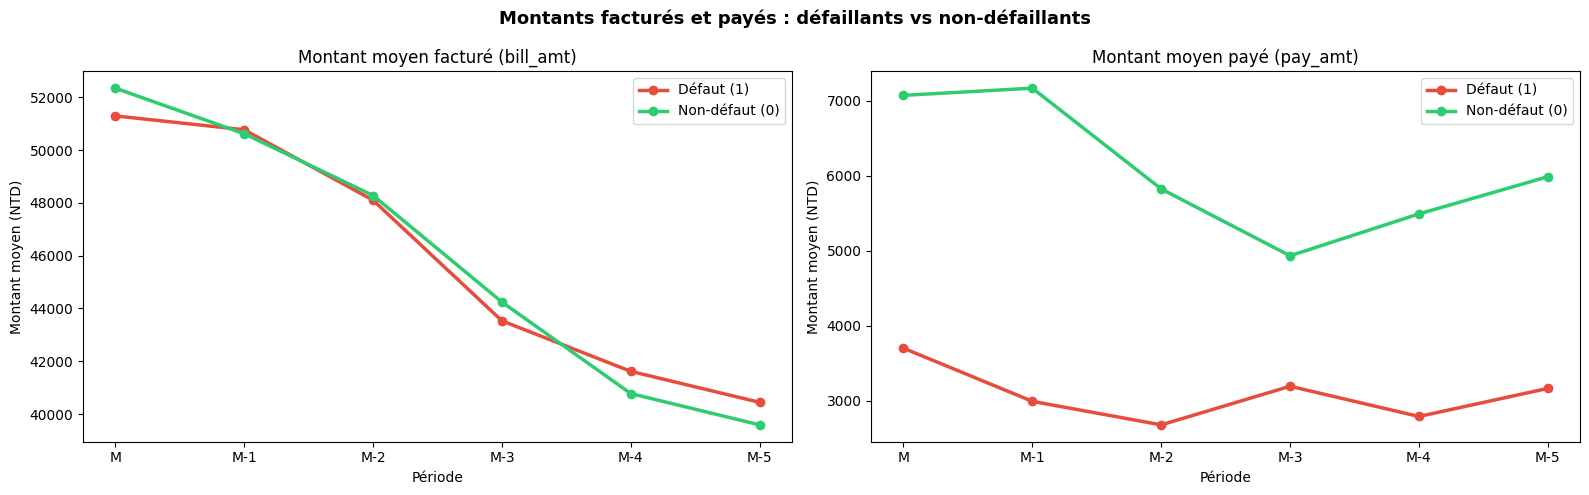

In [16]:
# ============================================================
# 6.2 — Évolution des montants facturés et payés dans le temps
# ============================================================
bill_means    = df.groupby(TARGET)[BILL_COLS].mean()
pay_amt_means = df.groupby(TARGET)[PAY_AMT_COLS].mean()
months6 = ["M", "M-1", "M-2", "M-3", "M-4", "M-5"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Montants facturés et payés : défaillants vs non-défaillants", fontsize=13, fontweight="bold")

for label_val, label_txt, color in [(1, "Défaut (1)", "#e74c3c"), (0, "Non-défaut (0)", "#2ecc71")]:
    axes[0].plot(months6, bill_means.loc[label_val].values, marker="o",
                 linewidth=2.5, label=label_txt, color=color)
    axes[1].plot(months6, pay_amt_means.loc[label_val].values, marker="o",
                 linewidth=2.5, label=label_txt, color=color)

axes[0].set_title("Montant moyen facturé (bill_amt)")
axes[0].set_xlabel("Période")
axes[0].set_ylabel("Montant moyen (NTD)")
axes[0].legend()

axes[1].set_title("Montant moyen payé (pay_amt)")
axes[1].set_xlabel("Période")
axes[1].set_ylabel("Montant moyen (NTD)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_bill_pay_trend.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation :**

- Les **défaillants** ont des montants facturés (`bill_amt`) comparables aux non-défaillants, mais des montants **payés très inférieurs**.
- Ce différentiel `bill_amt / pay_amt` est un signal de **tension de trésorerie** détectable bien avant le défaut.
- La divergence s'accumule dans le temps : un client qui paie peu depuis 3-4 mois est en situation de risque croissant.


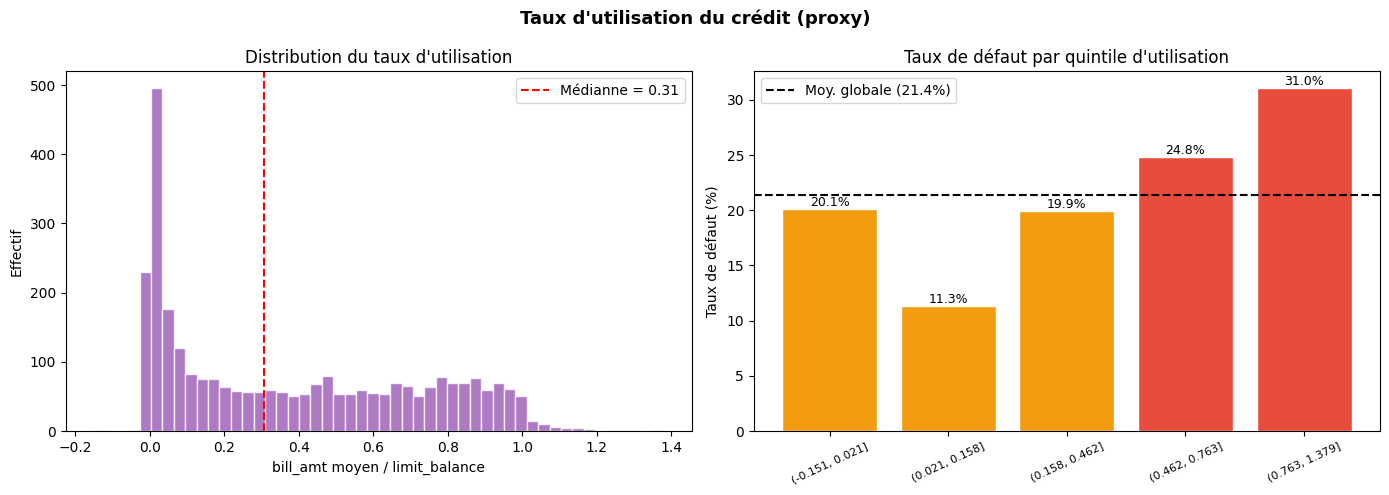

In [17]:
# ============================================================
# 6.3 — Taux d'utilisation du crédit (proxy = bill_amt moyen / limit_balance)
# ============================================================
df["avg_bill_amt"]    = df[BILL_COLS].mean(axis=1)
df["utilization_proxy"] = np.where(df["limit_balance"] > 0,
                                    df["avg_bill_amt"] / df["limit_balance"], np.nan)
df["util_bin"] = pd.qcut(df["utilization_proxy"].clip(-1, 2), q=5, duplicates="drop")
util_rate = df.groupby("util_bin", observed=True)[TARGET].agg(["count", "mean"]).reset_index()
util_rate["mean_pct"] = util_rate["mean"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Taux d'utilisation du crédit (proxy)", fontsize=13, fontweight="bold")

axes[0].hist(df["utilization_proxy"].clip(-0.5, 1.5), bins=50,
             color="#9b59b6", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribution du taux d'utilisation")
axes[0].set_xlabel("bill_amt moyen / limit_balance")
axes[0].set_ylabel("Effectif")
axes[0].axvline(df["utilization_proxy"].median(), color="red", linestyle="--",
                label=f"Médianne = {df['utilization_proxy'].median():.2f}")
axes[0].legend()

axes[1].bar(range(len(util_rate)), util_rate["mean_pct"],
            color=["#e74c3c" if v > df[TARGET].mean()*100 else "#f39c12" for v in util_rate["mean_pct"]],
            edgecolor="white")
axes[1].axhline(df[TARGET].mean() * 100, color="black", linestyle="--", linewidth=1.5,
                label=f"Moy. globale ({df[TARGET].mean()*100:.1f}%)")
axes[1].set_xticks(range(len(util_rate)))
axes[1].set_xticklabels([str(b) for b in util_rate["util_bin"]], rotation=25, fontsize=8)
axes[1].set_title("Taux de défaut par quintile d'utilisation")
axes[1].set_ylabel("Taux de défaut (%)")
axes[1].legend()
for i, row in util_rate.iterrows():
    axes[1].text(i, row["mean_pct"] + 0.3, f"{row['mean_pct']:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_utilization.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation :**

- Un **taux d'utilisation > 75 %** correspond à un taux de défaut ~31 % (vs 21 % en moyenne).
- Une faible utilisation n'est pas systématiquement protectrice : elle peut signaler une non-consommation liée à une situation de blocage.
- Cette variable dérivée (`utilization_proxy`) sera créée comme **feature dans la pipeline ML** (feature engineering).


## 7. Matrice de corrélation avec la cible


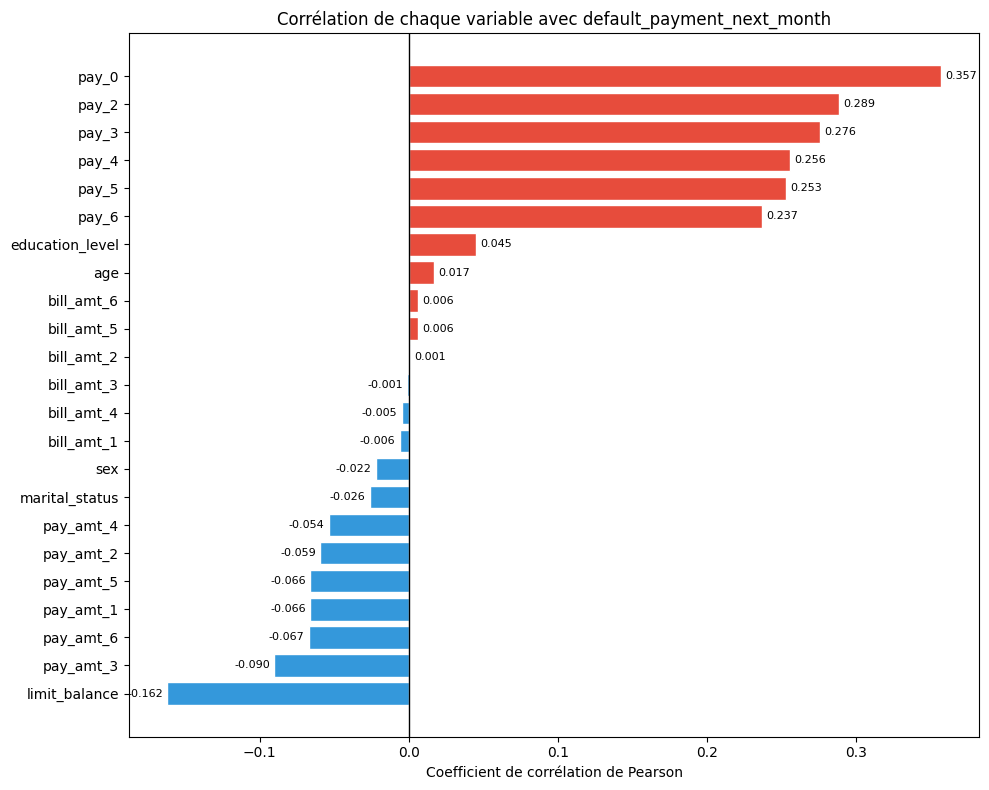

Top 5 corrélations positives (risque de défaut ↑) :
pay_0    0.356963
pay_2    0.288813
pay_3    0.275758
pay_4    0.255805
pay_5    0.253319

Top 5 corrélations négatives (risque de défaut ↓) :
pay_amt_5       -0.066159
pay_amt_1       -0.066163
pay_amt_6       -0.066966
pay_amt_3       -0.090248
limit_balance   -0.161909


In [18]:
# ============================================================
# 7.1 — Corrélations numériques avec la cible (barplot trié)
# ============================================================
numeric_cols = df_model.select_dtypes(include="number").columns.tolist()
corr_target  = df_model[numeric_cols].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ["#e74c3c" if v > 0 else "#3498db" for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors_bar[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Corrélation de chaque variable avec default_payment_next_month", fontsize=12)
ax.set_xlabel("Coefficient de corrélation de Pearson")
for i, (col, val) in enumerate(zip(corr_target.index[::-1], corr_target.values[::-1])):
    ax.text(val + 0.003 if val >= 0 else val - 0.003, i,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/09_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 corrélations positives (risque de défaut ↑) :")
print(corr_target.head(5).to_string())
print("\nTop 5 corrélations négatives (risque de défaut ↓) :")
print(corr_target.tail(5).to_string())


**Interprétation :**

- **Top 3 prédicteurs positifs** (hausse du risque) : `pay_0` (~0.357), `pay_2` (~0.289), `pay_3` (~0.276) — les retards récents dominent.
- **Top prédicteurs négatifs** (réduction du risque) : `limit_balance` (~-0.162), `pay_amt_3` (~-0.090).
- Les variables `pay_X` concentrent l'essentiel du signal prédictif ; les montants facturés (`bill_amt`) sont peu corrélés individuellement mais portent de l'information via la multicolinéarité.


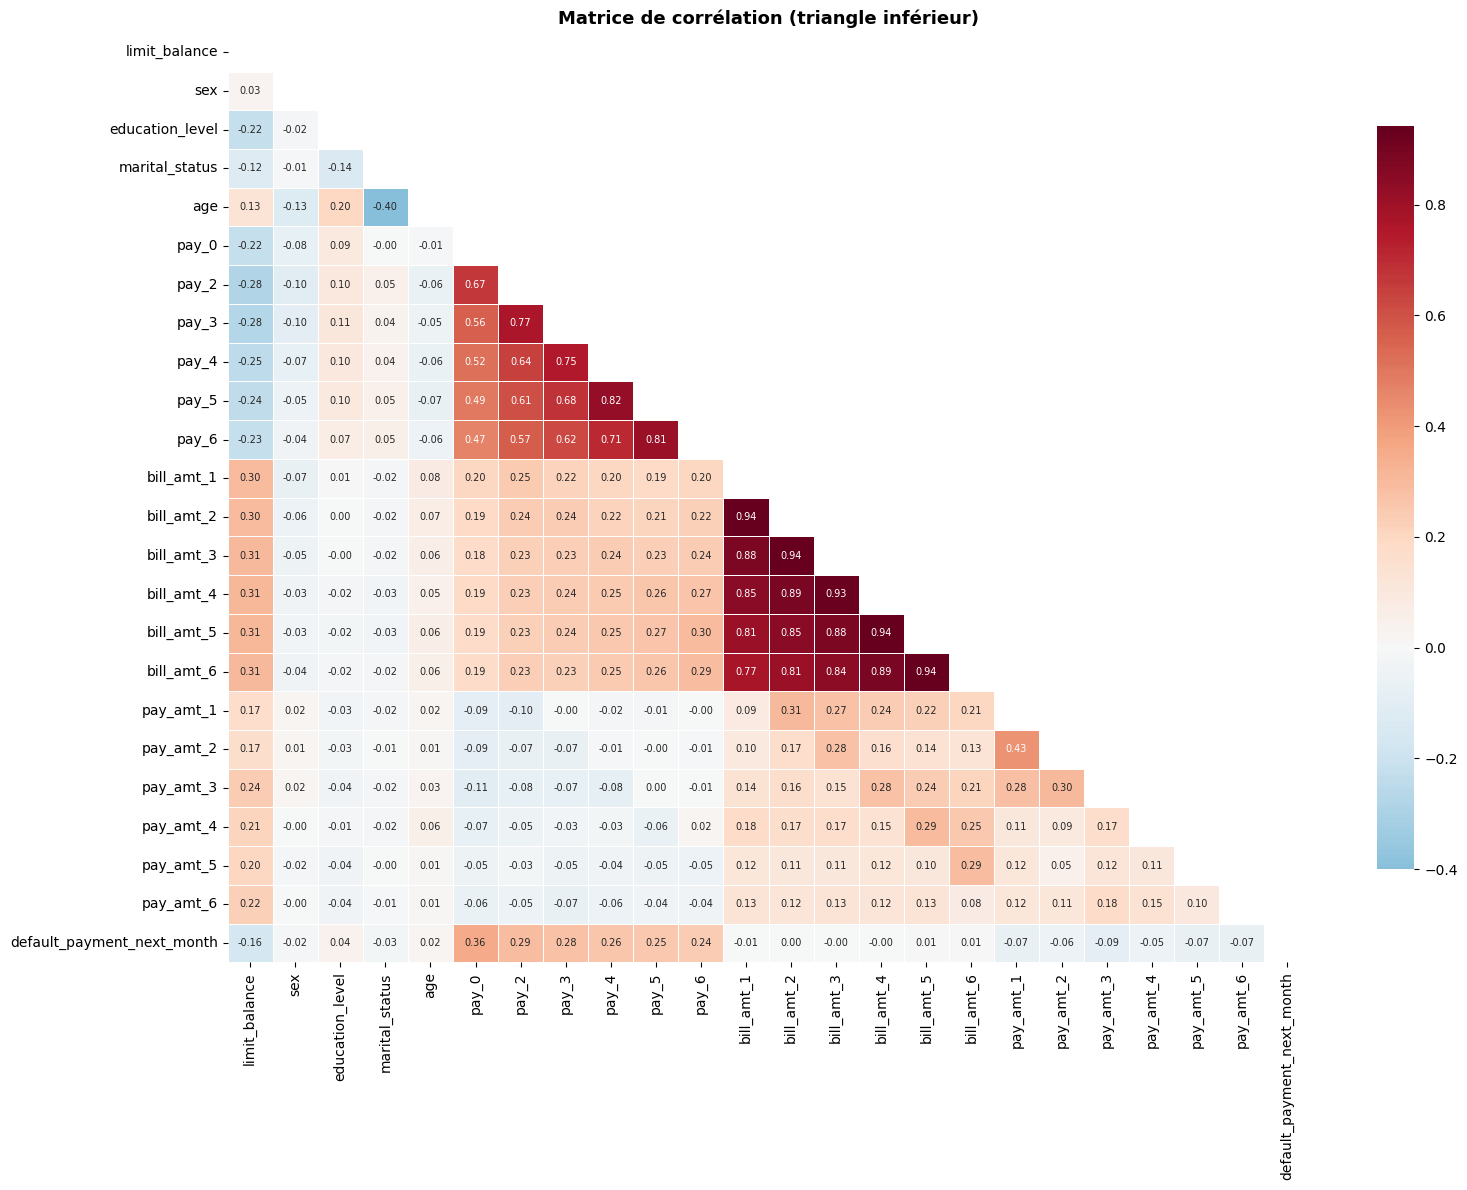

In [19]:
# ============================================================
# 7.2 — Heatmap complète de la matrice de corrélation
# ============================================================
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = df_model[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, annot_kws={"size": 7}, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Matrice de corrélation (triangle inférieur)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/10_corr_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation :**

- **Forte multicolinéarité** entre les `bill_amt_X` : la facturation mensuelle est très stable d'un mois sur l'autre → risque de redondance en modélisation.
- Les `pay_X` sont inter-corrélés mais restent les **meilleurs prédicteurs individuels** de la cible.
- `limit_balance` est **négativement corrélé** à la cible et aux statuts de paiement : les clients à forte limite remboursent mieux.


## 8. Synthèse EDA et protocole d'évaluation

### 8.1 — Principales conclusions

| Dimension | Constat | Impact sur la modélisation |
|---|---|---|
| **Qualité données** | 0 manquant, 0 doublon | Pipeline sans imputation complexe |
| **Codes aberrants** | `education_level` ∈ {0,4,5,6} = ~2.5% | Regrouper en catégorie "Autre" |
| **Leakage** | `predicted_default_payment_next_month` → ROC-AUC = 0.796 | **Exclue dès le chargement** via `df_model` |
| **Déséquilibre** | 78.4% classe 0 / 21.4% classe 1 | `class_weight='balanced'` ou SMOTE |
| **Meilleurs prédicteurs** | `pay_0`, `pay_2`, `pay_3` (corr. > 0.27) | Features à conserver en priorité |
| **Prédicteurs secondaires** | `limit_balance` (corr. = -0.16), `pay_amt_3` | Signal utile, moins fort |
| **Feature engineering** | `utilization_proxy` = bill_amt moyen / limit_balance | À créer dans la pipeline ML |

### 8.2 — Protocole d'évaluation recommandé

- **Split** : 80% train / 20% test, **stratifié** sur la cible, `random_state=1204` — ✅ défini en début de notebook
- **Métriques principales** : PR-AUC (prioritaire), Recall (classe 1), F1 (classe 1)
- **Métrique secondaire** : ROC-AUC (comparaison inter-modèles)
- **Seuil de décision** : définir un top K% à relancer (logique coût métier)
- **Traitement du déséquilibre** : tester `class_weight='balanced'` en baseline, puis SMOTE sur train uniquement
